<a href="https://colab.research.google.com/github/prasad123253/projects/blob/main/project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/superstore/SuperStoreOrders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [8]:
df.shape

(51290, 21)

In [9]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [10]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [11]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [12]:
df.dtypes

,0
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_name,object
segment,object
state,object
country,object
market,object
region,object


In [13]:
df["sales"].head(10)

,sales
0,408
1,120
2,66
3,45
4,114
5,55
6,314
7,276
8,912
9,667


In [14]:
df[df["category"]=="furniture"]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year


In [15]:
df.sort_values(by="sales",ascending=False).head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
40454,MX-2014-165260,28-06-2014,4/7/2014,Standard Class,Bruce Stewart,Consumer,Guatemala,Guatemala,LATAM,Central,...,Office Supplies,Appliances,"Hamilton Beach Refrigerator, Black",999,3,0.000,179.8200,75.80,Medium,2014
7602,CA-2011-121629,28-11-2011,2/12/2011,Standard Class,Brian Thompson,Consumer,Texas,United States,US,Central,...,Technology,Machines,StarTech.com 10/100 VDSL2 Ethernet Extender Kit,999,5,0.400,-199.7700,112.39,High,2011
14710,CA-2012-146563,24-08-2012,28-08-2012,Standard Class,Cassandra Brandow,Consumer,Texas,United States,US,Central,...,Office Supplies,Storage,"Hot File 7-Pocket, Floor Stand",999,7,0.200,124.9290,69.76,Medium,2012
5676,ES-2011-5251246,27-09-2011,29-09-2011,First Class,Filia McAdams,Corporate,Brittany,France,EU,Central,...,Technology,Copiers,"Sharp Fax Machine, High-Speed",999,4,0.150,70.4100,15.00,Medium,2011
8823,CA-2011-143371,28-12-2011,3/1/2012,Standard Class,Maribeth Dona,Consumer,California,United States,US,West,...,Office Supplies,Storage,"Carina Mini System Audio Rack, Model AR050B",999,9,0.000,29.9646,76.28,Medium,2011
20773,IN-2013-11448,6/2/2013,11/2/2013,Standard Class,Toby Carlisle,Consumer,Karnataka,India,APAC,Central Asia,...,Furniture,Tables,"Hon Training Table, with Bottom Storage",998,3,0.000,419.1300,61.25,Medium,2013
41056,MX-2014-130211,14-07-2014,16-07-2014,First Class,Bill Shonely,Corporate,São Paulo,Brazil,LATAM,South,...,Technology,Copiers,"HP Fax Machine, Laser",998,5,0.002,327.9004,213.78,High,2014
10548,KE-2012-4830,28-03-2012,30-03-2012,Second Class,Katherine Hughes,Consumer,Nairobi,Kenya,Africa,Africa,...,Office Supplies,Appliances,"Hamilton Beach Refrigerator, White",997,2,0.000,318.8400,176.43,High,2012
35266,IN-2014-65817,24-02-2014,28-02-2014,Standard Class,Corey Catlett,Corporate,Guangdong,China,APAC,North Asia,...,Technology,Copiers,"Hewlett Personal Copier, High-Speed",997,7,0.000,9.8700,102.62,Medium,2014
37015,ES-2014-1015287,16-04-2014,16-04-2014,Same Day,Brad Norvell,Corporate,England,United Kingdom,EU,North,...,Furniture,Bookcases,"Safco Floating Shelf Set, Mobile",996,5,0.000,119.5500,282.58,Critical,2014


In [16]:
df.sort_values(by="profit",ascending=False).head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
29530,CA-2013-118689,3/10/2013,10/10/2013,Standard Class,Tamara Chand,Corporate,Indiana,United States,US,Central,...,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"17,500",5,0.0,8399.9760,349.07,Medium,2013
36239,CA-2014-140151,24-03-2014,26-03-2014,First Class,Raymond Buch,Consumer,Washington,United States,US,West,...,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"14,000",4,0.0,6719.9808,20.00,Medium,2014
48097,CA-2014-166709,18-11-2014,23-11-2014,Standard Class,Hunter Lopez,Consumer,Delaware,United States,US,East,...,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"10,500",3,0.0,5039.9856,363.19,Medium,2014
33011,CA-2013-117121,18-12-2013,22-12-2013,Standard Class,Adrian Barton,Consumer,Michigan,United States,US,Central,...,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,"9,893",13,0.0,4946.3700,498.70,Medium,2013
5522,CA-2011-116904,23-09-2011,28-09-2011,Standard Class,Sanjit Chand,Consumer,Minnesota,United States,US,Central,...,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,"9,450",5,0.0,4630.4755,655.61,Medium,2011
43831,ES-2014-1651774,8/9/2014,14-09-2014,Standard Class,Patrick Jones,Corporate,Tuscany,Italy,EU,South,...,Office Supplies,Appliances,"Hoover Stove, Red","7,959",14,0.0,3979.0800,778.32,Low,2014
46525,CA-2014-127180,23-10-2014,25-10-2014,First Class,Tom Ashbrook,Home Office,New York,United States,US,East,...,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"11,200",4,0.2,3919.9888,45.98,High,2014
10265,CA-2012-145352,16-03-2012,22-03-2012,Standard Class,Christopher Martinez,Consumer,Georgia,United States,US,South,...,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,"6,355",5,0.0,3177.4750,581.12,Medium,2012
548,ID-2011-64599,10/2/2011,15-02-2011,Standard Class,Carol Adams,Corporate,Shizuoka,Japan,APAC,North Asia,...,Technology,Phones,"Samsung Smart Phone, VoIP","6,999",11,0.0,2939.3100,413.80,Medium,2011
24420,IN-2013-50809,12/6/2013,17-06-2013,Standard Class,Cynthia Arntzen,Consumer,Chhattisgarh,India,APAC,Central Asia,...,Technology,Phones,"Apple Smart Phone, with Caller ID","5,752",9,0.0,2817.9900,353.85,Medium,2013


In [17]:
df["sales"].sum()

'408120664511455314276912667338211854193159195123696913536526281476171,64822318614014916674383839271627171563,0292079027349124324509041392831202,57461039225644527471638817475645331551991431913272631718552,4792,174987397775011651024017715812452459102,87536358996814215515630942553206421142630343716211111731121691,3841,3234525546972453342681031881421571159778140555240225349538555252229034257101715161353177941,20020119838263150221691,3265736474865464403342243931061365124611099801097974662011376793527652265150512496217055451915211501,41230012712430849546371919177461083826144181457162262784841655348168253721811411965649109584837322410111392,7971,2441,06870040527727318249524810767856144616723395230271823191419151978898256666095202259219109546525776121,1029204826243491,303561591734202201336913955111415440594228126151144514817813371453298182043341,11357031128511931825612479343345142115108136888852324134861260916131117751421154901883677615523031638251201740351911175125323331329057362849336944416

In [18]:
df["sales"].max()

'999'

In [19]:
df["profit"].sum()

np.float64(1469034.8212799998)

In [20]:
df["profit"].mean()

np.float64(28.64173954533047)

In [21]:
df["profit"].max()

8399.976

In [22]:
df["profit"].min()

-6599.978

In [23]:
region_sales = df.groupby("region")[["sales", "profit"]].sum()
region_sales

,sales,profit
region,,
Africa,"408811562825645912,47959683091715161353177941,...",88871.63100
Canada,3141627737973057551246493301212601705312381504...,17817.39000
Caribbean,1863838392651835853061940542319277827714517239...,34571.32104
Central,1951401620790273124324716331555987397775011610...,311403.98164
Central Asia,"142597934328641232022141,211150401233001182071...",132480.18700
EMEA,6666712352624717174263635891421551565342371111...,43897.97100
East,2010373621271243019465115196151361133021262545...,91522.78000
North,"4585422316627173,029206114161,3841,32345224510...",194597.95252
North Asia,"2749312,174263498367401641633521,0523816924689...",165578.42100


In [24]:
category_sales = df.groupby("category")[["sales","profit"]].sum()
category_sales

,sales,profit
category,,
Furniture,"114667211854159691,64838493242,574155262,47998...",286782.25380
Office Supplies,4081206645552763381231353652628147617186140149...,518473.83430
Technology,"3149121931956922316638283924452743881747562,17...",663778.73318


In [25]:
df["sales"].head(10)

,sales
0,408
1,120
2,66
3,45
4,114
5,55
6,314
7,276
8,912
9,667


In [28]:
print(df["sales"].dtype)

int64


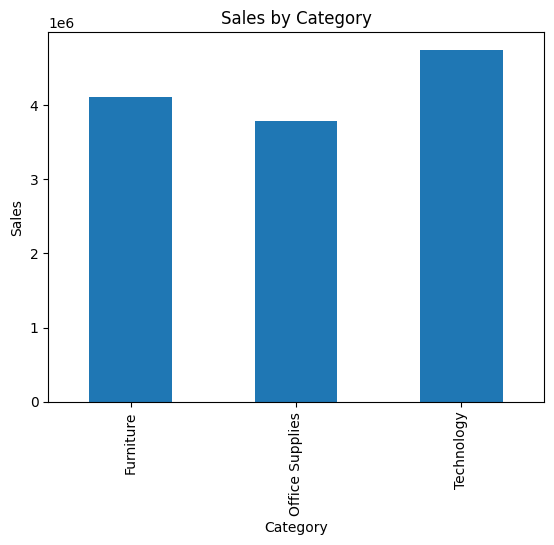

In [29]:
df.groupby("category")["sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

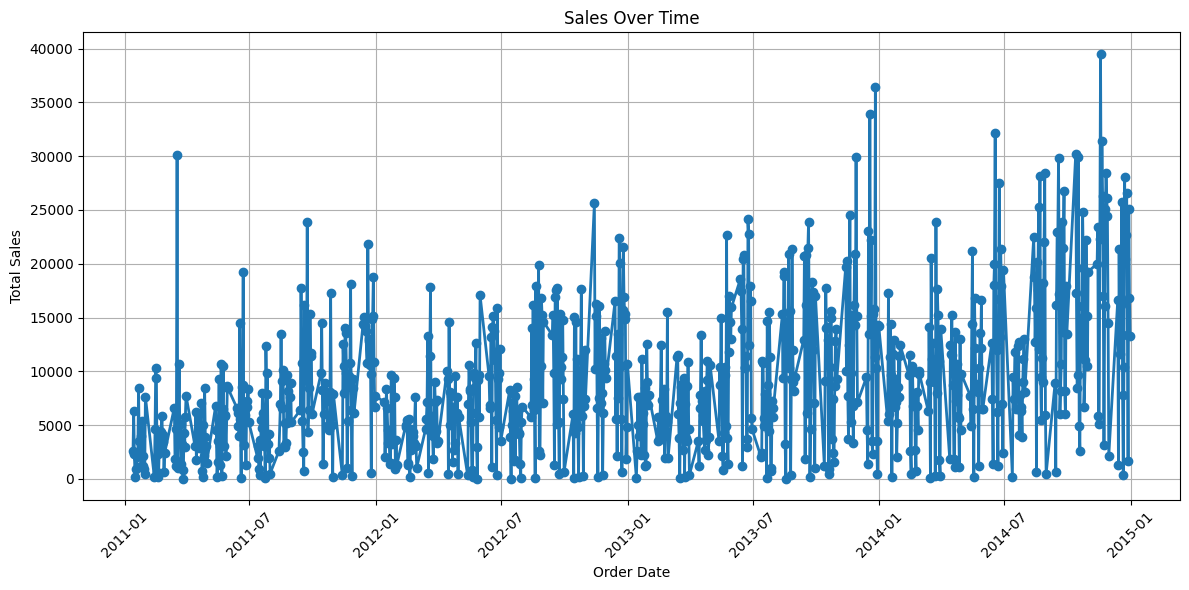

In [31]:
sales_time = df.groupby("order_date")["sales"].sum().sort_index()


plt.figure(figsize=(12,6))
plt.plot(sales_time.index, sales_time.values,
         marker='o', linewidth=2)

plt.title("Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

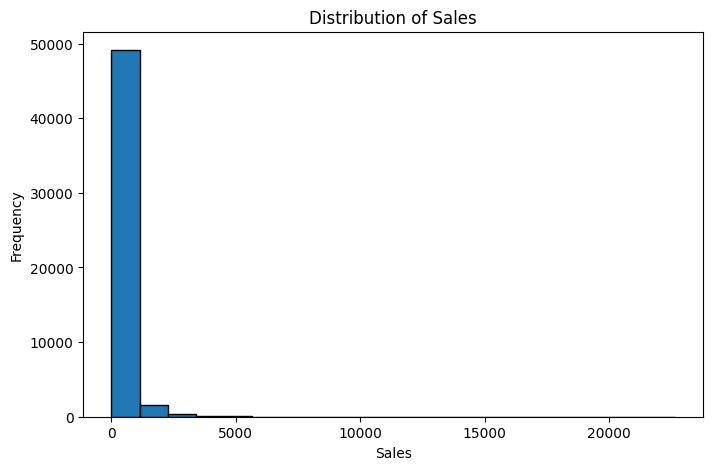

In [32]:
df["sales"] = pd.to_numeric(
    df["sales"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

plt.figure(figsize=(8,5))
plt.hist(df["sales"], bins=20, edgecolor="black")

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

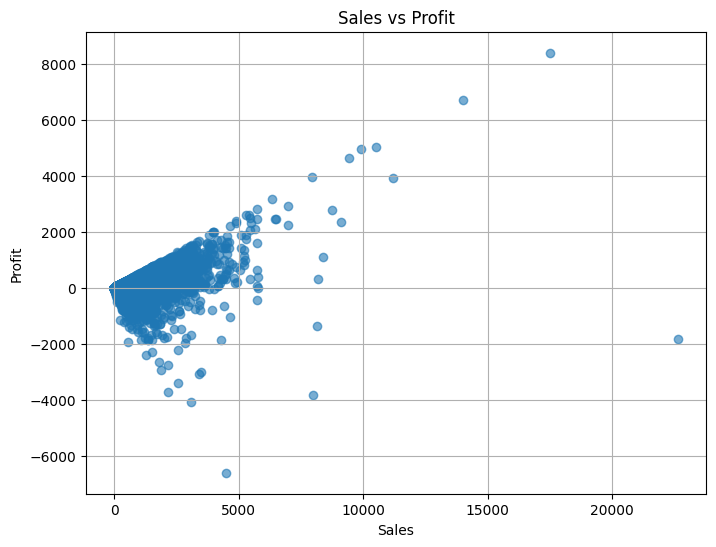

In [33]:
df["sales"] = pd.to_numeric(
    df["sales"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

plt.figure(figsize=(8,6))
plt.scatter(df["sales"], df["profit"], alpha=0.6)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)

plt.show()

In [34]:
print("""
                                  EXECUTIVE SUMMARY

Imported and clean data.
Performed filtering and sorting.
Calculated sales and profit statistics.
Analyze region-wise and category-wise performance.
Created:
Bar chart
Line chart
Histogram
Scatter plot
""")


                                  EXECUTIVE SUMMARY 

Imported and clean data.
Performed filtering and sorting.
Calculated sales and profit statistics.
Analyze region-wise and category-wise performance.
Created:
Bar chart
Line chart
Histogram
Scatter plot

